***Monte Carlo Simulator***
- simulates multiple possible scenarios so that you can calculate statistical properties of the outcomes.
- outcomes may include: expectations, variances of probabilities, etc.

$$
\frac{C_{t}}{B_{t}} = \mathbb{E}_{\mathbb{Q}}\left[\frac{C_{T}}{B_{T}} \mid \mathcal{F}_{t}\right]
$$

**Note:** This is the Risk-neutral Expectation Pricing Formula in Continuous Time.

Types of financial problems:
1. portfolio statistics (Brownian motion of Real probabilities under P-measure)
- Expected returns
- Risk metrics (VaR, CVaR, etc.)
- Downside risks (Drawdown metrics)
- other probabilities of interest

2. Pricing derivatives with risk-neutral  pricing (Brownian motion is representative of risk-neutral probabilities under Q-measure)

--------------------------------------------------------------------------------------------------------------------------------------

Project saved in GitHub - Jan 2022 project

In [3]:
#import dependencies
import math
import numpy as np
import pandas as pd
import datetime
import scipy.stats as stats
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import yfinance as yf

[*********************100%***********************]  9 of 9 completed


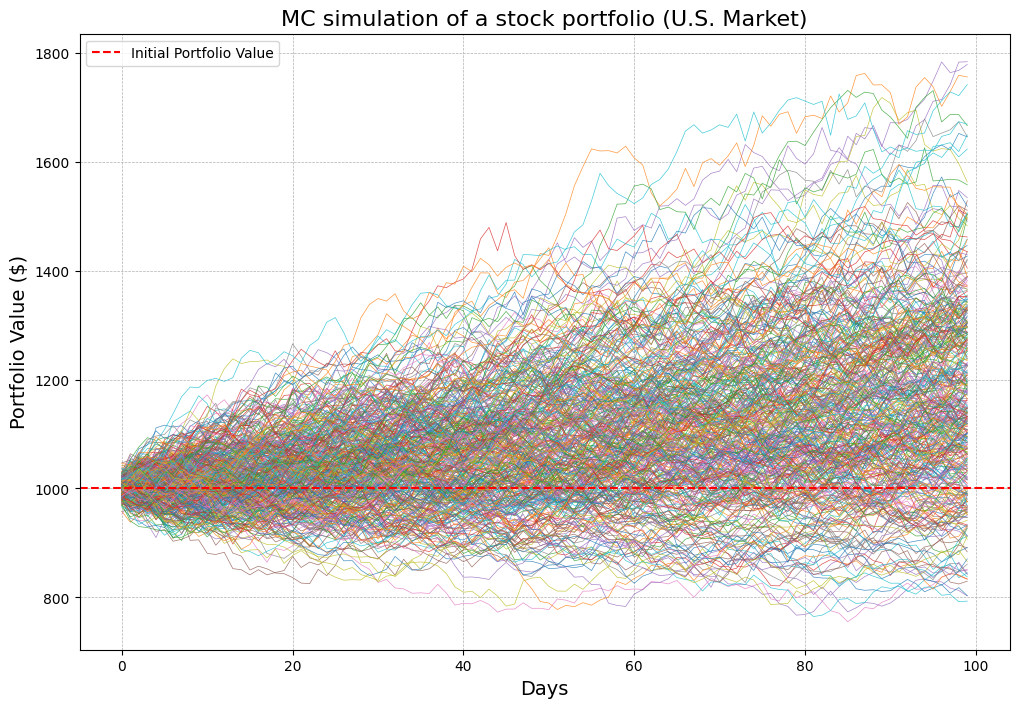

Value At Risk (VaR_5): $1000.0
Conditional Value At Risk (CVaR_5): $1000.0


In [4]:
#import data
#get_Data function for stocks & date
def get_data(stocks, start, end):
    #stockData = pdr.get_data_yahoo(stocks, start, end)
    #stockData = stockData['Close']

#Download the data first if unable to fetch directly
    stockData = yf.download(stocks, start=start, end=end, group_by='ticker')
    if stockData is None or stockData.empty:
        raise ValueError("Failed to fetch data. Check the ticker symbols & internet connection.")

    #Find closing price for each stock
    closePrices = pd.DataFrame({stock: stockData[stock]['Close'] for stock in stocks
                                if stock in stockData})
    returns = closePrices.pct_change()
    meanReturns = returns.mean()
    covMatrix = returns.cov()
    return meanReturns, covMatrix

stockList = ['NVDA', 'TSLA', 'ACHR', 'ASTS', 'AMZN', 'SPY', 'VOO', 'QQQ', 'TTWO']
#American markets do not need a suffix
stocks = stockList
#.AX is the Australian market bro
#stocks = [stock + '.AX' for stock in stockList]

#Getting the time interval for the stocks
endDate = datetime.datetime.now()
startDate = endDate - datetime.timedelta(days=300)

meanReturns, covMatrix = get_data(stocks, startDate, endDate)

weights = np.random.random(len(meanReturns))
weights /= np.sum(weights)

#Monte Carlo Method
mc_sims = 400 #no. of simulations
T = 100 #timeframe (days)

meanM = np.full(shape=(T, len(weights)), fill_value = meanReturns)
meanM = meanM.T

#running various portfolio simulations
portfolio_sims = np.full(shape=(T, mc_sims), fill_value = 0.0)

#giving money to the portfolio
initialPortfolio = 1000

#Risk metrics
def mcVaR(returns, alpha=5):
    """ Input: pandas series of returns
        Output: percentile on return distribution to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        return np.percentile(returns, alpha)
    else:
        raise TypeError("Expected a pandas data series.")

def mcCVaR(returns, alpha=5):
    """ Input: pandas series of returns
        Output: CVaR or Expected shortfall to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        belowVaR = returns <= mcVaR(returns, alpha=alpha)
        return returns[belowVaR].mean()
    else:
        raise TypeError("Expected a pandas data series.")

portResults = pd.Series(portfolio_sims[-1,:])
VaR = initialPortfolio - mcVaR(portResults, alpha=5)
cVaR = initialPortfolio- mcCVaR(portResults, alpha=5)

#finding values for the simulations
for m in range (0, mc_sims):
    Z = np.random.normal(size = (T, len(weights))) #Uncorrelated RV's
    L = np.linalg.cholesky(covMatrix) #Cholesky decomposition to Lower Triangular Matrix
    dailyReturns = meanM + np.inner(L, Z) #Correlated daily returns for indv stocks
    portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T)+1) * initialPortfolio


plt.figure(figsize=(12,8))
plt.plot(portfolio_sims, linewidth = 0.5, alpha = 0.8)
plt.ylabel('Portfolio Value ($)', fontsize = 14)
plt.xlabel('Days', fontsize = 14)
plt.title('MC simulation of a stock portfolio (U.S. Market)', fontsize = 16)
plt.grid(True, which='both', linestyle = '--', linewidth=0.5)
plt.axhline(y=initialPortfolio, color='r', linestyle = '--', 
            label = 'Initial Portfolio Value')
plt.legend()
plt.show()

print('Value At Risk (VaR_5): ${}'.format(round(VaR,2)))
print('Conditional Value At Risk (CVaR_5): ${}'.format(round(cVaR,2)))

**Computationally Inefficient**
- Not as efficient as other deterministic PDE's, (e.g. Black-Scholes model for European options)
- We can instead use:

1. Variance Reduction Methods
- Antithetic Variates
- Control Variates

2. Quasi-random numbers (deterministic series) over pseudo-random numbers


Valuation by Simulation

The risk-neutral pricing methodology tells us that:
- value of an option = risk-neutral expectation of its discounted payoff

  We can estimate this expectation by computing the average of a large number of discounted payoffs. For a particular simulation i:

$$C_{0,i} = \exp \left( - \int_0^T r_s \, ds \right) C_{T,i} = \exp ( - r T ) C_{T,i}$$

Now if we repeat the simulation ***M*** times, we can average the outcomes. $\hat{C}_0 = \tfrac{1}{M} \sum_{i=1}^M C_{0,i}$


**Standard Error**
[] is an estimate of the true value of the option [] with error BECAUSE we ar taking an average of RANDOMLY generated samples (i.e calculation in itself will be random). The measure of the standard deviation of [] == standard error.

$$\begin{align*}
SE(\hat{C}_0) &= \frac{\sigma (C_{0,i})}{\sqrt{M}} \\
\sigma (C_{0,i}) &= \sqrt{\frac{1}{M-1} \sum_{i=1}^{M} (C_{0,i} - \hat{C}_0)^2}
\end{align*}$$


**European Call Option in the Black-Scholes World**

Here we have the constant interest rate == discount factor is exp(-rT).
- Stock dynamics are modelled with Geometric Brownian Motion (GBM).

$$
\mathit{dS}_{t} = r S_{t} \mathit{dt} + \sigma S_{t} \mathit{dW}_{t}
$$

By simulating this GBM Process by simulating variables of the *Natural Logarithm* process of the stock price (normal distribution).

$$x_{t} = \log(S_{t})$$
Implementing the above equation into the previous equation:

$$dx_{t} = \nu \, dt + \sigma \, dz_{t}, \quad \nu = r - \frac{1}{2} \sigma^{2}$$

We then discretize the Stochastic Differential Equation (SDE) by changing the infinitesimals dx, dt, dz into SMALL steps delta(x), delta(t), delta(z).


In [4]:
# Initial derivative parameters

S = 101.15    #stock price
K = 98.01     #strike price
vol = 0.0991  #volatility (%)
r = 0.01      #risk-free rate(%)
N = 10        #No. of time steps
M = 1000      #No. of simulations

market_value = 3.86  #market price of given option

T = ((datetime.date(2022, 3, 17)-datetime.date(2022,1,17)).days + 1)/365  
     #Finding time in years
print(T)

0.1643835616438356


In [ ]:
#Slow solution: Start by computing manually

#Precompute constants
dt = T/N
nudt = (r - 0.5*vol**2)*dt
volsdt = vol*np.sqrt(dt)
lnS = np.log(S)

#Standard error placeholders
sum_CT = 0
sum_CT2 = 0

# MONTE CARLO METHOD
for i in range(M):
    lnSt = lnS
    for j in range(N):
        lnSt = lnSt + nudt + volsdt*np.random.normal()

    ST = np.exp(lnSt)
    CT = max(0, ST - K)
    sum_CT = sum_CT + CT